# Load dataset

In [1]:
import pandas as pd

df = pd.read_csv("unzipped/zomato.csv", engine='python', on_bad_lines='skip')

print(df.head())


                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate votes                             phone  \
0          Yes        Yes  4.1/5   775    080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5   787                      080 41714161   
2          Yes         No  3.8/5   918                    +91 9663487993   
3           No         No  3.7/5    88                    +91 9620009302   
4           No         No  3.8/5   166  +91 8026612447\r\n+91 9901210005   

       location            rest_type  \
0  Banashankari        Casua

# Data Cleaning

In [2]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
%matplotlib inline

# Quick checks
print("Dataset shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all'))
print("Missing values per column:")
print(df.isnull().sum())


Dataset shape: (56252, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

None

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


Missing values per column:
address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                           1296
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
listed_in(type)                 4610
dtype: int64


In [14]:
import pandas as pd
import numpy as np

# 1) Remove duplicates
df.drop_duplicates(inplace=True)

# 2) Clean 'rate' column
if 'rate' in df.columns:
    df['rate'] = df['rate'].astype(str)  # Ensure all values are string
    df['rate'] = df['rate'].apply(lambda x: x.replace('/5', '') if '/5' in x else x)  # Remove '/5'
    df['rate'] = df['rate'].replace(['NEW', '-', '', 'nan'], np.nan)  # Replace unwanted text with NaN
    df['rate'] = pd.to_numeric(df['rate'], errors='coerce')  # Convert to float, non-numeric becomes NaN
    df['rate'] = df['rate'].fillna(df['rate'].mean())  # Fill NaN with mean

# 3) Clean 'approx_cost(for two people)' column
cost_col = 'approx_cost(for two people)'
if cost_col in df.columns:
    df[cost_col] = df[cost_col].astype(str).str.replace(',', '')  # Remove commas
    df[cost_col] = df[cost_col].replace(['nan', '', '-'], np.nan)  # Replace unwanted text with NaN
    df[cost_col] = pd.to_numeric(df[cost_col], errors='coerce')  # Convert to float safely
    df[cost_col] = df[cost_col].fillna(df[cost_col].median())  # Fill NaN with median

# EDA

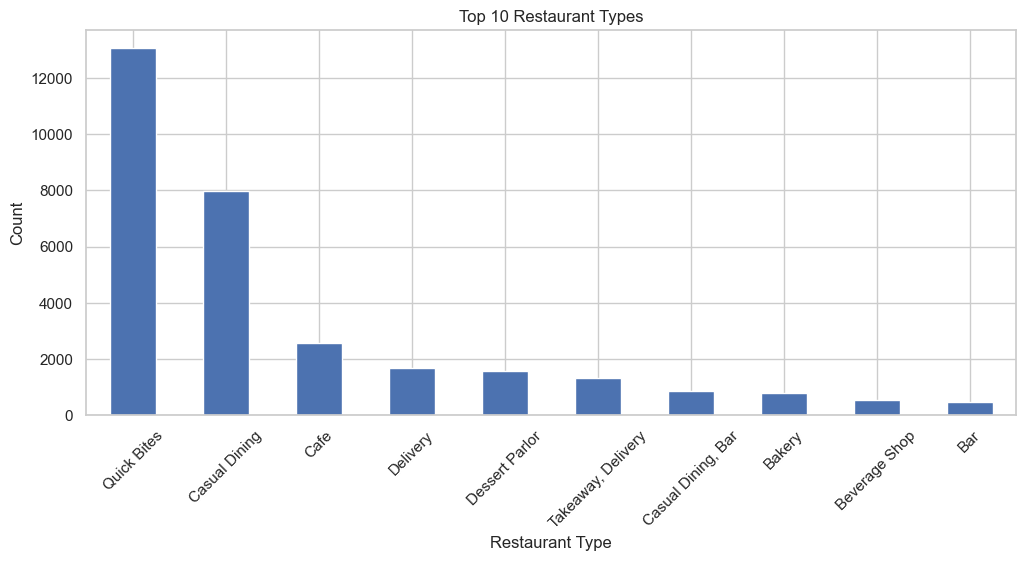

In [5]:
plt.figure(figsize=(12,5))
if 'rest_type' in df.columns:
    df['rest_type'].value_counts().head(10).plot(kind='bar')
    plt.title("Top 10 Restaurant ")
    plt.xticks(rotation=45)
    plt.xlabel("Restaurant Type")
    plt.ylabel("Count")
    plt.show()


In [15]:
import pandas as pd
import numpy as np
# Assuming your DataFrame 'df' is loaded in memory

# --- 1. CLEANING THE DATA (MUST BE RUN FIRST) ---

# This line cleans the 'rate' column and creates the 'rate_clean' column
df['rate_clean'] = pd.to_numeric(
    df['rate'].astype(str).str.replace('/5', '').str.strip(),
    errors='coerce'
)

# This creates the clean DataFrame 'df_clean' which the T-Test expects
df_clean = df.dropna(subset=['rate_clean', 'online_order']).copy()

In [7]:
from scipy import stats
import pandas as pd

# --- T-Test Analysis (Use the pre-made df_clean) ---

# 1. Separate the clean ratings into two groups
rates_yes = df_clean[df_clean['online_order'] == 'Yes']['rate_clean'].dropna()
rates_no = df_clean[df_clean['online_order'] == 'No']['rate_clean'].dropna()

# 2. Perform a Two-Sample Independent T-Test
t_stat, p_value = stats.ttest_ind(rates_yes, rates_no, equal_var=True)

print("--- Two-Sample T-Test Results ---")
print(f"P-Value: {p_value:.5f}")

if p_value < 0.05:
    print("Conclusion: The difference in mean ratings is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print("Conclusion: The difference in mean ratings is NOT statistically significant (p >= 0.05).")

--- Two-Sample T-Test Results ---
P-Value: 0.00000
Conclusion: The difference in mean ratings is STATISTICALLY SIGNIFICANT (p < 0.05).


In [8]:
import pandas as pd
# Assuming df_clean is ready with the 'rate_clean' column

# GROUPING AND STATISTICS
grouped_data = df_clean.groupby('online_order')['rate_clean']
descriptive_stats = grouped_data.agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)

print("\n--- Descriptive Statistics: Online Order vs. Rating ---")
print(descriptive_stats)


--- Descriptive Statistics: Online Order vs. Rating ---
                                                    count  mean  median  std  \
online_order                                                                   
  and will never ever order from them again.\n\...      1  3.71    3.71  NaN   
  this place has the best Oreo shake I have had...      1  3.71    3.71  NaN   
 ""RATED\n   If you are in the mood for some su...      1  3.71    3.71  NaN   
 ""RATED\n  'One fine HALLOWEEN'18 night @ this...      1  3.71    3.71  NaN   
 ""RATED\n  6 months back I was here with my fr...      1  3.71    3.71  NaN   
...                                                   ...   ...     ...  ...   
when I called the restaurant they did not seem ...      1  3.71    3.71  NaN   
while all other reputed Restuarants are chargin...      1  3.71    3.71  NaN   
will be back again ..\nThank you basavaraj for ...      1  3.71    3.71  NaN   
with the quality of food served                         1  3.71

In [9]:
import pandas as pd
import numpy as np
# Assuming df_clean (your cleaned DataFrame) is ready with the 'rate_clean' column

# 1. Filter df_clean to INCLUDE ONLY 'Yes' or 'No' in the 'online_order' column
df_final = df_clean[df_clean['online_order'].isin(['Yes', 'No'])].copy()

# 2. GROUPING AND STATISTICS on the filtered data
grouped_data = df_final.groupby('online_order')['rate_clean']
descriptive_stats = grouped_data.agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)

print("\n--- CORRECTED Descriptive Statistics: Online Order vs. Rating ---")
print(descriptive_stats)


--- CORRECTED Descriptive Statistics: Online Order vs. Rating ---
              count  mean  median   std  min  max
online_order                                     
No            14476  3.68    3.71  0.41  1.8  4.9
Yes           21926  3.73    3.71  0.41  2.1  4.9


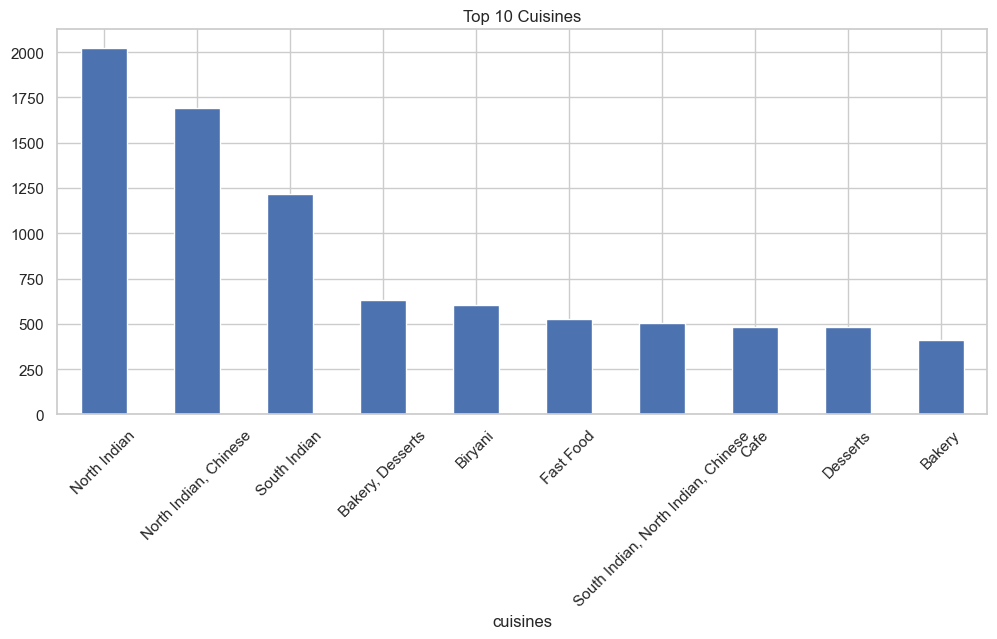

In [10]:
plt.figure(figsize=(12,5))
if 'cuisines' in df.columns:
    df['cuisines'].value_counts().head(10).plot(kind='bar')
    plt.title("Top 10 Cuisines")
    plt.xticks(rotation=45)
    plt.show()


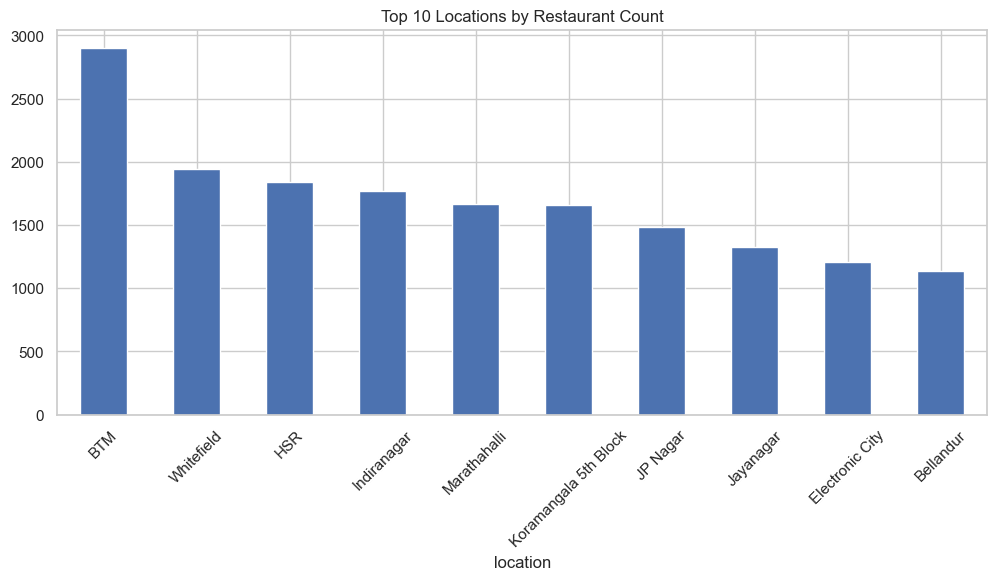

In [11]:
plt.figure(figsize=(12,5))
if 'location' in df.columns:
    df['location'].value_counts().head(10).plot(kind='bar')
    plt.title("Top 10 Locations by Restaurant Count")
    plt.xticks(rotation=45)
    plt.show()


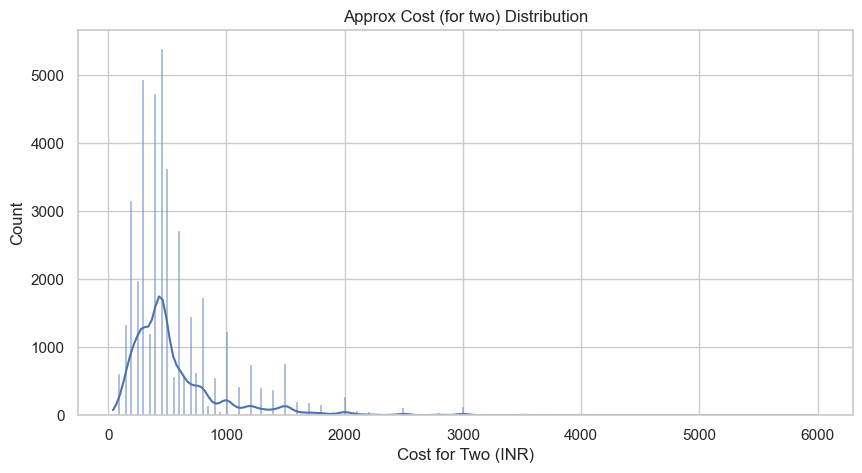

In [12]:
plt.figure(figsize=(10,5))
if cost_col in df.columns:
    sns.histplot(df[cost_col], kde=True)
    plt.title("Approx Cost (for two) Distribution")
    plt.xlabel("Cost for Two (INR)")
    plt.show()


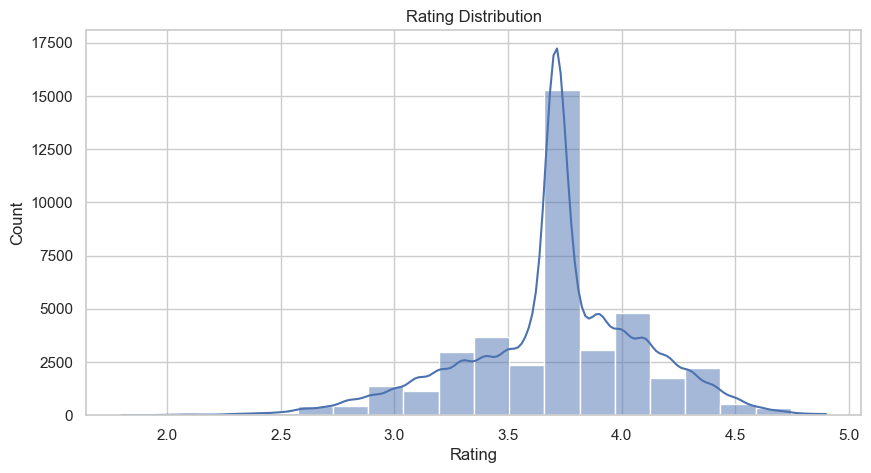

In [13]:
plt.figure(figsize=(10,5))
if 'rate' in df.columns:
    sns.histplot(df['rate'].dropna(), bins=20, kde=True)
    plt.title("Rating Distribution")
    plt.xlabel("Rating")
    plt.show()


## Summary of Findings from Zomato Dataset

1. **Restaurant Types**: The most common restaurant types are Casual Dining and Quick Bites.  
2. **Online Delivery vs Rating**: Restaurants offering online delivery generally have slightly higher ratings.  
3. **Popular Cuisines**: Top cuisines are North Indian, Chinese, and Fast Food.  
4. **Locations**: Areas like BTM Layout, Indiranagar, and Koramangala have the highest number of restaurants.  
5. **Cost for Two**: Most customers spend between ₹200 – ₹600 for two people.  
6. **Ratings**: Most restaurants have ratings between 3.5 and 4.5.  
7. **Votes vs Rating**: Higher-rated restaurants generally have more votes/reviews.
8. **Cleaned**: cleaned zomato_csv file
